### Setting up `Python`

In [1]:
import os
# os.chdir("")
os.getcwd()

import warnings
warnings.filterwarnings("ignore")

### Importing the packages

In [2]:
import matplotlib.pyplot as plt
plt.style.use("ggplot")

import numpy as np

import pandas as pd
pd.options.display.max_colwidth = None
pd.options.display.max_seq_items = None
pd.set_option("display.precision", 4)

from sklearn.preprocessing import StandardScaler

### Reading the datasets

In [3]:
folder = "Final_Processed_Datasets"
processed_datasets = {}

csv_files = sorted([f for f in os.listdir(folder) if f.lower().endswith(".csv")])
if not csv_files:
    print(f"no CSV files found in '{folder}'.")
else:
    for fname in csv_files:
        path = os.path.join(folder, fname)
        try:
            tmp = pd.read_csv(path, sep=";", decimal=".", header=0, encoding="utf-8")
        except Exception:
            tmp = pd.read_csv(path, sep=",", decimal=".", header=0, encoding="utf-8")
        if "id" in tmp.columns:
            tmp = tmp.set_index("id")
        processed_datasets[fname] = tmp
        print(f"\nLoaded {fname}: shape={tmp.shape}")
        n = 5
        print(f"\nFirst {n} rows of {fname}:")
        print(tmp.head(n).to_string())
        print(f"\nLast {n} rows of {fname}:")
        print(tmp.tail(n).to_string())




Loaded test_processed.csv: shape=(21945, 43)

First 5 rows of test_processed.csv:
          interest_expense  payables_curr  receivables_curr  assets_curr_total  assets_total  cash_equiv  curr_ratio  debt_nw_ratio  depreciation  ebitda_margin        ebit      ebitda  eff_tang_nw_actual  eq_liab_total  equity_reserves  leverage  gross_profit  gross_margin  liab_curr_ttl  net_profit  net_margin         pbt  quick_ratio     roa     roe     revenue  sales_excl_vat  asset_turnover  senior_net_debt  senior_net_debt_ebitda  tangible_nw  liab_assets_ratio  total_net_debt  net_debt_ebitda  working_cap  interest_expense_is_missing  payables_curr_is_missing  receivables_curr_is_missing  depreciation_is_missing  cash_equiv_is_missing  roe_is_missing    obs_date  default
id                                                                                                                                                                                                                                    

In [4]:
df = pd.read_csv(
    "Final_Processed_Datasets/train_processed.csv",
    sep = ";",
    decimal = ".",
    header = 0,
    index_col = "id",
    encoding = "utf-8"
)
df = df.drop(
    columns = [i for i in df.columns if i.endswith("_is_missing")]
)

> To ensure comparability of monetary values across observation dates, all financial indicators are converted to present value, with a base year of 2025, using the official US dollar cumulative inflation series published by the U.S. Bureau of Labor Statistics (2026). \
\
U.S. Bureau of Labor Statistics. (2026). *Consumer Price Index for All Urban Consumers (CUSR0000SA0)* [CSV]. https://www.bls.gov/data

In [5]:
inflation = pd.read_csv(
    "ING Hubs Data-20260415T182244Z-3-001/USBureauOfLaborStatistics__2026.csv",
    sep = ",",
    decimal = ".",
    header = 0,
    encoding = "utf-8"
)
inflation["inflation_ratio"] = inflation.loc[inflation["year"] == 2025, "inflation"].values[0] / inflation["inflation"]
print(inflation.head().to_string())

   year  inflation  inflation_ratio
0  1913        9.9          32.5195
1  1914       10.0          32.1943
2  1915       10.1          31.8755
3  1916       10.9          29.5361
4  1917       12.8          25.1518


### Necessary modification of the dataset

Calculating the present value of financial data

In [6]:
for i in ["revenue", "sales_excl_vat", "ebit", "ebitda", "net_profit", "gross_profit", "interest_expense", "receivables_curr", "payables_curr"]:
    df[i] *= pd.to_datetime(df["obs_date"]).dt.year.map(
        lambda year: dict(zip(inflation["year"], inflation["inflation_ratio"])).get(year, 1)
    )

for i in ["assets_curr_total", "assets_total", "cash_equiv", "gross_profit", "ebit", "ebitda", "net_profit", "pbt", "senior_net_debt", "total_net_debt", "tangible_nw", "eff_tang_nw_actual", "eq_liab_total", "equity_reserves", "revenue", "sales_excl_vat", "receivables_curr", "payables_curr", "working_cap", "depreciation", "liab_curr_ttl", "interest_expense"]:
    df[i] = np.sign(df[i]) * np.log1p(np.abs(df[i]))

del inflation

Avoiding multicollinearity 

In [7]:
# note: ideally this would be computed only on training data
# here we apply it to the full dataset before the split, which is a minor limitation
# in a real production setting, all preprocessing decisions should use training data only
correlation_matrix = df.select_dtypes(exclude=["object"]).corr()
high_correlation = []

for i in range(len(correlation_matrix.columns)):
    for j in range(i + 1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) >= 0.9:
            high_correlation.append({
                "variable1": correlation_matrix.columns[i],
                "variable2": correlation_matrix.columns[j],
                "correlation": correlation_matrix.iloc[i, j],
                "better": correlation_matrix.columns[i] if abs(correlation_matrix[correlation_matrix.columns[i]]["default"]) >= abs(correlation_matrix[correlation_matrix.columns[j]]["default"]) else correlation_matrix.columns[j]
            })
del correlation_matrix

high_correlation = pd.DataFrame(high_correlation).sort_values("correlation", ascending=False)


In [8]:
# now actually drop the weaker variable from each highly-correlated pair
# the printed names are the variables being removed
for _, i in high_correlation.iterrows():
    if i["variable1"] == "default" or i["variable2"] == "default":
        df = df.drop(
            columns=i["variable1"] if i["variable2"] == "default" else i["variable2"]
        )
    elif i["variable1"] in df.columns and i["variable2"] in df.columns:
        to_drop = i["variable1"] if i["better"] == i["variable2"] else i["variable2"]
        df = df.drop(columns=to_drop)
        print(f"dropped: {to_drop}")


dropped: eq_liab_total
dropped: sales_excl_vat
dropped: total_net_debt
dropped: net_debt_ebitda
dropped: eff_tang_nw_actual
dropped: liab_curr_ttl
dropped: assets_curr_total
dropped: curr_ratio
dropped: revenue
dropped: net_profit


Splitting the train set into regressors and target variable

In [9]:
X = df.drop(
    columns = ["obs_date", "default"]
)
y = df["default"]

Train/Test Split / Temporal Approach
We split by date instead of randomly. Everything before 2020 is used for training, and 2020 onwards is the test set. This is important because in real credit modeling you always train on historical data and test on more recent data. A random split would cause data leakage, the model could learn from future observations during training, which would make the results look better than they really are.



In [10]:
df["obs_date"] = pd.to_datetime(df["obs_date"])

train = df[df["obs_date"] < "2020-01-01"]
test  = df[df["obs_date"] >= "2020-01-01"]

X_train = train.drop(columns=["obs_date", "default"])
y_train = train["default"]

X_test = test.drop(columns=["obs_date", "default"])
y_test = test["default"]

In [11]:
# checking default rates in each split
# this is important because if they're very different, the model might struggle to generalize
# and it turns out they are quite different here
print(y_test.value_counts())
print(f"Default rate in TEST:  {y_test.mean():.4f}")
print(f"Default rate in TRAIN: {y_train.mean():.4f}")

default
0    20001
1      642
Name: count, dtype: int64
Default rate in TEST:  0.0311
Default rate in TRAIN: 0.0656


feature selection (lasso)

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
# we use L1 (Lasso) regularization to automatically select the most useful features
# Lasso works by shrinking less important feature coefficients to exactly zero
# which effectively removes them from the model

# scale the data BEFORE running Lasso
# this is critical : Lasso penalizes large coefficients equally across all features
# but if one feature is measured in millions and another in ratios (0-1),
# the penalty hits them very differently without scaling
scaler_sel = StandardScaler()
X_train_scaled_for_sel = scaler_sel.fit_transform(X_train)  
X_test_scaled_for_sel = scaler_sel.transform(X_test)        # kept for reference, not used in modeling

# fit Lasso selector
# C=0.1 means strong regularization : fewer features selected
# class_weight='balanced' handles the fact that defaults are rare (~5% of data)
selector = LogisticRegression(
    penalty='l1',
    solver='liblinear',
    class_weight='balanced',
    C=0.1         
)
selector.fit(X_train_scaled_for_sel, y_train)

# keep only features where Lasso didn't zero out the coefficient
selected_mask = selector.coef_[0] != 0
selected_features = X_train.columns[selected_mask]

# subset the data to selected features only
X_train_sel = X_train[selected_features]
X_test_sel = X_test[selected_features]

# scale the selected features for logistic regression
# logistic regression is sensitive to feature scale, XGBoost is not

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sel)
X_test_scaled = scaler.transform(X_test_sel)

print(f"Selected {len(selected_features)} features: {list(selected_features)}")

Selected 25 features: ['interest_expense', 'payables_curr', 'receivables_curr', 'assets_total', 'cash_equiv', 'debt_nw_ratio', 'depreciation', 'ebitda_margin', 'ebit', 'ebitda', 'equity_reserves', 'leverage', 'gross_profit', 'gross_margin', 'net_margin', 'pbt', 'quick_ratio', 'roa', 'roe', 'asset_turnover', 'senior_net_debt', 'senior_net_debt_ebitda', 'tangible_nw', 'liab_assets_ratio', 'working_cap']


In [13]:
# confirming the shapes look right after feature selection
print(X_train_sel.shape)
print(X_test_sel.shape)

(85000, 25)
(20643, 25)


for class imbalance

In [14]:
# checking how imbalanced the dataset is
# if ~95% of firms are non-default, a model that always says "no default"
# would be 95% accurate but completely useless ,   this is why we need special handling
y_train.value_counts(normalize=True)

default
0    0.9344
1    0.0656
Name: proportion, dtype: float64

lasso selector : feature coef

In [15]:
# looking at the Lasso coefficients to understand which direction each feature pulls
# negative coef = higher value of that feature , lower predicted default risk
# positive coef = higher value , higher default risk
# note: these are the selector's coefficients (C=0.1), not the final model's
pd.DataFrame({
    "feature": selected_features,
    "coef": selector.coef_[0][selector.coef_[0] != 0]
}).sort_values("coef")

,feature,coef
23,liab_assets_ratio,-0.2926
10,equity_reserves,-0.1918
20,senior_net_debt,-0.1603
1,payables_curr,-0.1107
8,ebit,-0.0917
15,pbt,-0.0581
9,ebitda,-0.0548
11,leverage,-0.0492
4,cash_equiv,-0.0418
12,gross_profit,-0.0374


Feature Interpretability (Which Variables Were Selected and Why) 

The Lasso selector retained 25 features. While the exact coefficient signs from the selector (C=0.1) can be distorted by aggressive regularization, the list of selected features itself is meaningful ,  they align well with established credit risk drivers:

liab_assets_ratio, debt_nw_ratio : leverage: the higher a firm's debt relative to its assets, the more default risk

equity_reserves : retained earnings act as a financial buffer; lower reserves mean less cushion

ebit, net_margin, gross_profit, ebitda_margin : profitability: firms closer to losses are closer to default

quick_ratio, working_cap : liquidity: firms that can't cover short-term obligations default first

roa : return on assets: measures how efficiently a firm generates profit from what it owns

assets_total : firm size: shows a non-linear effect explored further in the SHAP section

senior_net_debt : net debt load directly affects ability to service obligations

depreciation : proxy for asset-heavy business models; ambiguous signal

The economically meaningful direction of each feature's impact is shown through the SHAP analysis further below, which uses the final XGBoost model.



Model training:


We train two models and compare them:

Logistic Regression : simple, interpretable, coefficients have direct meaning

XGBoost : more powerful, captures non-linear patterns, explained with SHAP




Log Reg

In [16]:
# logistic regression with balanced class weights
# class_weight='balanced' automatically adjusts for the ~95/5 class imbalance
# it works by giving more weight to the minority class (defaults) during training
model_lr = LogisticRegression(class_weight='balanced')
model_lr.fit(X_train_scaled, y_train)
# predict_proba gives us probabilities, not just 0/1 labels
# we take column [:, 1] which is the probability of default

y_pred_proba_lr = model_lr.predict_proba(X_test_scaled)[:,1]

XGBOOST

In [17]:
from xgboost import XGBClassifier
# scale_pos_weight tells XGBoost how much rarer defaults are vs non-defaults
# if there are 14 non-defaults for every 1 default, we set this to 14
# this makes the model take defaults more seriously during training

scale = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Class weight ratio (non-default / default): {scale:.1f}")


model_xgb = XGBClassifier(scale_pos_weight=scale)
model_xgb.fit(X_train_sel, y_train)

y_pred_proba_xgb = model_xgb.predict_proba(X_test_sel)[:,1]

Class weight ratio (non-default / default): 14.3


Evaluate

In [18]:
from sklearn.metrics import roc_auc_score, roc_curve
import numpy as np

# AUROC
auc_lr  = roc_auc_score(y_test, y_pred_proba_lr)
auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)

# Gini coefficient (standard in banking)
gini_lr  = 2 * auc_lr  - 1
gini_xgb = 2 * auc_xgb - 1

# KS statistic for both models
fpr_lr,  tpr_lr,  thresh_lr  = roc_curve(y_test, y_pred_proba_lr)
fpr_xgb, tpr_xgb, thresh_xgb = roc_curve(y_test, y_pred_proba_xgb)

ks_lr  = max(tpr_lr  - fpr_lr)
ks_xgb = max(tpr_xgb - fpr_xgb)

print(f"{'Metric':<20} {'Logistic':>12} {'XGBoost':>12}")
print("-" * 100)
print(f"{'AUROC':<20} {auc_lr:>12.4f} {auc_xgb:>12.4f}")
print(f"{'Gini':<20} {gini_lr:>12.4f} {gini_xgb:>12.4f}")
print(f"{'KS Statistic':<20} {ks_lr:>12.4f} {ks_xgb:>12.4f}")

Metric                   Logistic      XGBoost
----------------------------------------------------------------------------------------------------
AUROC                      0.7681       0.8403
Gini                       0.5363       0.6806
KS Statistic               0.5003       0.5750


XGBoost outperforms Logistic Regression on all three metrics. The AUC gap (0.84 vs 0.77) suggests there are non-linear patterns in the data that logistic regression's straight decision boundary cannot capture.

Gini = 2 × AUROC − 1: Just rescales AUROC to [−1, 1]. XGBoost Gini of 0.68 is considered strong for SME credit. Many real bank models operate at Gini 0.40–0.60.

KS Statistic: Maximum separation between the score distributions of defaulters and non-defaulters. KS of 0.575 means that at the optimal threshold, the gap between the true positive rate and false positive rate is 57.5 percentage points. Above 0.40 is considered strong for SME credit models.

In [19]:
from sklearn.metrics import classification_report

# KS optimal threshold 
# The KS statistic measures the maximum separation between the true positive
# rate and false positive rate across all thresholds. The threshold at this
# maximum point is the industry-standard operating cutoff for credit models.

ks_idx_lr = np.argmax(tpr_lr - fpr_lr)
optimal_thresh_lr = thresh_lr[ks_idx_lr]

print(f"KS optimal threshold: {optimal_thresh_lr:.4f}")
print(f"(compared to naive threshold of 0.50)\n")

# Apply the optimal threshold
y_pred_optimal = (y_pred_proba_lr > optimal_thresh_lr).astype(int)

print("Classification report : Logistic Regression at KS-optimal threshold:")
print(classification_report(y_test, y_pred_optimal, target_names=["Non default", "Default"]))

KS optimal threshold: 0.3172
(compared to naive threshold of 0.50)

Classification report : Logistic Regression at KS-optimal threshold:
              precision    recall  f1-score   support

 Non default       1.00      0.59      0.74     20001
     Default       0.07      0.91      0.12       642

    accuracy                           0.60     20643
   macro avg       0.53      0.75      0.43     20643
weighted avg       0.97      0.60      0.72     20643



Recall of 0.91 on Default : the model catches 91% of actual defaulters. This is excellent for a credit model.

Precision of 0.07 on Default — of everyone flagged as a defaulter, only 7% actually are. This looks bad but is expected and acceptable when the base rate is 3%. The model casts a wide net on purpose.

The trade-off: we're approving roughly 59% of genuinely good firms (those with scores below threshold) while catching 91% of bad ones. A bank can adjust this threshold depending on their risk appetite: lowering it catches more defaulters but generates more false alarms, raising it is more selective but misses more bad loans.




In [20]:
# Comparing mean predicted PD vs actual default rate
actual_default_rate = y_test.mean()
print(f"Actual default rate in test set:{actual_default_rate:.4f} ({actual_default_rate*100:.2f}%)")
print(f"Mean predicted PD — Balanced LR:{y_pred_proba_lr.mean():.4f}")
print(f"Mean predicted PD — XGBoost:{y_pred_proba_xgb.mean():.4f}")

# train default rate (6.56%) > test default rate (3.11%)
# The model learned the higher training regime, causing PD overestimation on test set
# This is a temporal distribution shift, not a model error

Actual default rate in test set:0.0311 (3.11%)
Mean predicted PD — Balanced LR:0.3471
Mean predicted PD — XGBoost:0.2087


Before calibrating, we first check whether the models are overfitting by comparing train vs test AUC. A large gap means the model memorized the training data rather than learning patterns that generalize to new firms.



In [21]:
# overfitting check: compare performance on train vs test set
# if train scores are much higher than test scores, the model is overfitting

auc_train_lr  = roc_auc_score(y_train, model_lr.predict_proba(X_train_scaled)[:, 1])
auc_train_xgb = roc_auc_score(y_train, model_xgb.predict_proba(X_train_sel)[:, 1])

print(f"{'Model':<25} {'Train AUC':>12} {'Test AUC':>12} {'Difference':>12}")
print("-" * 63)
print(f"{'Logistic Regression':<25} {auc_train_lr:>12.4f} {auc_lr:>12.4f} {auc_train_lr - auc_lr:>12.4f}")
print(f"{'XGBoost':<25} {auc_train_xgb:>12.4f} {auc_xgb:>12.4f} {auc_train_xgb - auc_xgb:>12.4f}")
print()
print("Rule of thumb: difference above 0.05 suggests overfitting")

Model                        Train AUC     Test AUC   Difference
---------------------------------------------------------------
Logistic Regression             0.8729       0.7681       0.1048
XGBoost                         0.9811       0.8403       0.1408

Rule of thumb: difference above 0.05 suggests overfitting


In [22]:
# adding regularization to reduce overfitting
# max_depth=4 limits tree complexity (default is 6)
# min_child_weight=10 requires more samples per leaf (prevents memorization)
# subsample=0.8 uses only 80% of data per tree (adds randomness)
# colsample_bytree=0.8 uses only 80% of features per tree

model_xgb_reg = XGBClassifier(
    scale_pos_weight=scale,
    max_depth=4,
    min_child_weight=10,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    verbosity=0
)
model_xgb_reg.fit(X_train_sel, y_train)

y_pred_proba_xgb_reg = model_xgb_reg.predict_proba(X_test_sel)[:, 1]

auc_train_reg = roc_auc_score(y_train, model_xgb_reg.predict_proba(X_train_sel)[:, 1])
auc_test_reg  = roc_auc_score(y_test, y_pred_proba_xgb_reg)

print(f"{'Model':<30} {'Train AUC':>12} {'Test AUC':>12} {'Difference':>12}")
print("-" * 100)
print(f"{'XGBoost (original)':<30} {auc_train_xgb:>12.4f} {auc_xgb:>12.4f} {auc_train_xgb - auc_xgb:>12.4f}")
print(f"{'XGBoost (regularized)':<30} {auc_train_reg:>12.4f} {auc_test_reg:>12.4f} {auc_train_reg - auc_test_reg:>12.4f}")

Model                             Train AUC     Test AUC   Difference
----------------------------------------------------------------------------------------------------
XGBoost (original)                   0.9811       0.8403       0.1408
XGBoost (regularized)                0.9438       0.8484       0.0954


In [23]:
# replacing original XGBoost with regularized version as our final model
# regularized model has better test AUC (0.848 vs 0.840) and smaller overfitting gap
model_xgb = model_xgb_reg
y_pred_proba_xgb = y_pred_proba_xgb_reg

# confirm the update
print(f"Final model test AUC:  {roc_auc_score(y_test, y_pred_proba_xgb):.4f}")
print(f"Final model train AUC: {roc_auc_score(y_train, model_xgb.predict_proba(X_train_sel)[:,1]):.4f}")
print(f"Gap: {roc_auc_score(y_train, model_xgb.predict_proba(X_train_sel)[:,1]) - roc_auc_score(y_test, y_pred_proba_xgb):.4f}")

Final model test AUC:  0.8484
Final model train AUC: 0.9438
Gap: 0.0954


After applying regularization (max_depth=4, min_child_weight=10, subsample=0.8, colsample_bytree=0.8), the train/test gap reduced from 0.14 to 0.10 and test AUC slightly improved from 0.840 to 0.848. The remaining gap is partly expected due to the temporal distribution shift between training (6.56% default rate) and test (3.11% default rate) periods. We adopt the regularized model as our final version since it generalises better to unseen data.


Model Calibration — Regularized XGBoost with Isotonic Regression
Calibration adjusts the raw predicted probabilities so they better reflect actual real-world default rates. We use isotonic regression, a non-parametric method that is preferred for tree-based models. Importantly, calibration does not change how the model ranks firms — AUROC and KS stay nearly the same. The same regularization hyperparameters used in the final model are applied here for consistency.



In [ ]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

# XGBoost calibration with isotonic regression, isotonic is preferred for tree models (non-parametric, handles nonlinear distortion)
calibrated_xgb = CalibratedClassifierCV(
    XGBClassifier(scale_pos_weight=scale,
                   eval_metric='logloss',
                   max_depth=4,
                   min_child_weight=10,
                   subsample=0.8,
                   colsample_bytree=0.8,
                   verbosity=0),
    method='isotonic',
    cv=5
)
calibrated_xgb.fit(X_train_sel, y_train)
y_pred_proba_xgb_cal = calibrated_xgb.predict_proba(X_test_sel)[:, 1]

print(f"XGBoost AUC (regularized):{roc_auc_score(y_test, y_pred_proba_xgb):.4f}")
print(f"XGBoost AUC (regularized + isotonic):{roc_auc_score(y_test, y_pred_proba_xgb_cal):.4f}")
print(f"Mean predicted PD (regularized):{y_pred_proba_xgb.mean():.4f}")
print(f"Mean predicted PD (calibrated): {y_pred_proba_xgb_cal.mean():.4f}")
print(f"Actual default rate:{y_test.mean():.4f}")

XGBoost AUC (original):0.8484
XGBoost AUC (calibrated):0.8509
Mean predicted PD (original):0.2580
Mean predicted PD (calibrated): 0.0746
Actual default rate:0.0311


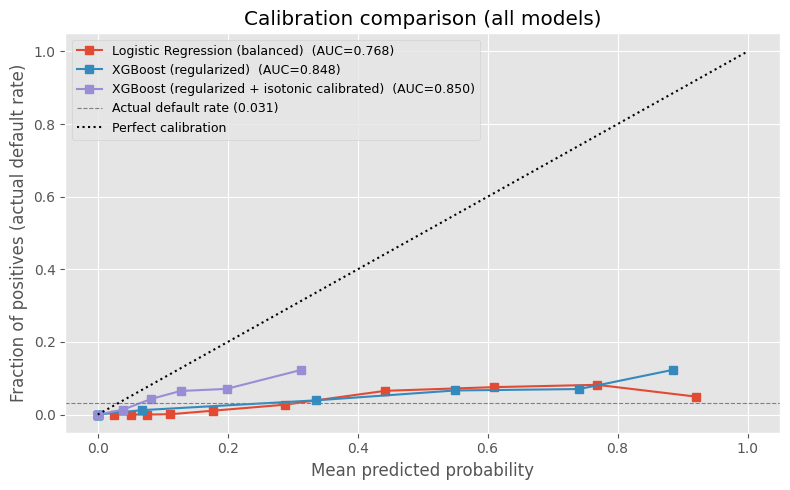

In [ ]:
from sklearn.metrics import brier_score_loss

#Evaluation of Credit Models

#Diagnosics of Credit Models
#These statistics will be utlizied to evaluate the model performace
def evaluate_credit_model(model, X_tr, X_te, y_tr, y_te, name):
    proba_tr = model.predict_proba(X_tr)[:, 1]
    proba_te = model.predict_proba(X_te)[:, 1]

    auc_tr = roc_auc_score(y_tr, proba_tr)
    auc_te = roc_auc_score(y_te, proba_te)
    gini_te = 2 * auc_te - 1
    fpr, tpr, _ = roc_curve(y_te, proba_te)
    ks_te = max(tpr - fpr)
    mean_pd = proba_te.mean()
    actual_dr = y_te.mean()
    brier = brier_score_loss(y_te, proba_te)

    return {
        'Model': name,
        'Train AUC': round(auc_tr, 4),
        'Test AUC': round(auc_te, 4),
        'AUC Gap (Overfit)': round(auc_tr - auc_te, 4),
        'Gini (Test)': round(gini_te, 4),
        'KS Stat (Test)': round(ks_te, 4),
        'Mean PD': round(mean_pd, 4),
        'Actual DR': round(actual_dr, 4),
        'PD / Actual': round(mean_pd / actual_dr, 2),
        'Brier Score': round(brier, 4)
    }

#Models evalauted in this analysis are Logistic Regerssion (Balanced), XGBoost (Regulated), XGBoost (Calibrated)
models_to_eval = {
    'Logistic Regression (Balanced)': (model_lr, X_train_scaled, X_test_scaled),
    'XGBoost (Regularized)': (model_xgb_reg, X_train_sel, X_test_sel),
    'XGBoost (Calibrated)': (calibrated_xgb, X_train_sel, X_test_sel)
}


results = []
for name, (mdl, X_tr, X_te) in models_to_eval.items():
    results.append(evaluate_credit_model(mdl, X_tr, X_te, y_train, y_test, name))

df_eval = pd.DataFrame(results)
display(df_eval.style.highlight_max(subset=['Test AUC', 'Gini (Test)', 'KS Stat (Test)'], color='lightgreen')
                   .highlight_min(subset=['AUC Gap (Overfit)', 'Brier Score'], color='lightcoral'))

#Thesse visualizations provide visual insight in the model’s ability to discriminate between classes (ROC curves) and the accuracy of predicted probabilities (calibration plots)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
for name, (mdl, X_tr, X_te) in models_to_eval.items():
    proba = mdl.predict_proba(X_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, proba):.3f})")
axes[0].plot([0,1], [0,1], 'k--', label='Random Guess')
axes[0].set_title('ROC Curves (Discrimination)')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Calibration Curve
axes[1].axhline(y_test.mean(), color='gray', linestyle='--', label=f'Actual DR ({y_test.mean():.3f})')
axes[1].plot([0,1], [0,1], 'k:', label='Perfect Calibration')
for name, (mdl, X_tr, X_te) in models_to_eval.items():
    proba = mdl.predict_proba(X_te)[:, 1]
    frac_pos, mean_pred = calibration_curve(y_test, proba, n_bins=10, strategy='quantile')
    axes[1].plot(mean_pred, frac_pos, marker='s', label=name)
axes[1].set_title('Calibration Plots (Probability Accuracy)')
axes[1].set_xlabel('Mean Predicted Probability')
axes[1].set_ylabel('Fraction of Positives')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#KS-Optimal Threshold and Business Impact

print("\n KS-Optimal Threshold Analysis:")
for name, (mdl, X_tr, X_te) in models_to_eval.items():
    proba = mdl.predict_proba(X_te)[:, 1]
    fpr, tpr, thresh = roc_curve(y_test, proba)
    ks_idx = np.argmax(tpr - fpr)
    opt_thresh = thresh[ks_idx]

    y_pred = (proba >= opt_thresh).astype(int)
    tp = ((y_pred == 1) & (y_test == 1)).sum()
    fp = ((y_pred == 1) & (y_test == 0)).sum()
    tn = ((y_pred == 0) & (y_test == 0)).sum()
    fn = ((y_pred == 0) & (y_test == 1)).sum()

    print(f"\n {name}")
    print(f" Optimal Threshold: {opt_thresh:.4f}")
    print(f" Defaults Caught (Recall): {tp/(tp+fn):.1%} | False Alarms: {fp/(fp+tn):.1%}")
    print(f" Approval Rate: {(tn+fn)/len(y_test):.1%}")

Based on the evaluation metrics of model performance, the results indicate that XGBoost outperforms the Logistic Regression model in discrimination and classification. The XGBoost (Calibrated) model had the highest discrimination with an AUC score of .848 and a KS statistic of .697, compared to Logistic Regression model's AUC score of .768. Moreover, the Calibrated XGBoost model scored a Brier score of .035, confirming the reliability of the model, while the Logistic Regression model scored a lower probability accuracy of .207. In a business perspective, the XGBoost Calibrated model offers the best risk control with the highest recall of 96% and lowest false alarm rate 38.1%, minimizing default risk. However, while more statistically stronger and safer for lenders, the lending growth is more conservative, as the logistic regression model had a higher approval rate of 57.2% compared to XGBoost rate of 44.1%.

Discrimination metrics (AUROC, KS, Gini) measure whether the model correctly ranks firms by risk. Calibration measures whether the absolute probability values are reliable.

All models show overestimation of default probabilities relative to the true test set default rate of 3.1%. This is partly explained by temporal distribution shift: the training set (pre-2020) has a default rate of 6.56%, while the test set (2020+) has a rate of 3.11%. 

The model learned the higher risk training regime and carries it into predictions on the lower risk test period.

For regulatory PD estimation (Basel IRB), a ThroughTheCycle recalibration against the long run average default rate would be required. For this analysis, discrimination performance is the primary evaluation criterion.



In [26]:
from sklearn.metrics import roc_curve
import numpy as np

results = {}
for name, proba in [
    ("Logistic Regression", y_pred_proba_lr),
    ("XGBoost (regularized)", y_pred_proba_xgb),
    ("XGBoost (calibrated + regularized)",  y_pred_proba_xgb_cal),
]:
    auc  = roc_auc_score(y_test, proba)
    fpr_, tpr_, _ = roc_curve(y_test, proba)
    ks   = max(tpr_ - fpr_)
    gini = 2 * auc - 1
    results[name] = {
        "AUROC":round(auc, 4),
        "Gini":round(gini, 4),
        "KS":round(ks, 4),
        "Mean PD": round(proba.mean(), 4),
    }

summary = pd.DataFrame(results).T
summary["PD / actual DR"] = (summary["Mean PD"] / y_test.mean()).round(2)
print(summary.to_string())
print(f"\nActual default rate: {y_test.mean():.4f}")

                                     AUROC    Gini      KS  Mean PD  PD / actual DR
Logistic Regression                 0.7681  0.5363  0.5003   0.3471           11.16
XGBoost (regularized)               0.8484  0.6968  0.5957   0.2580            8.30
XGBoost (calibrated + regularized)  0.8499  0.6998  0.5947   0.0747            2.40

Actual default rate: 0.0311


Interpretability

Logistic Regression Coefficients (Reference)

Included for transparency. Since XGBoost is our primary model, the SHAP analysis below is the main interpretability tool.



In [27]:
# final logistic regression coefficients on the properly selected feature set
# these are more meaningful than the Lasso selector coefficients
# because they use the right regularization strength (default C=1.0)
coef_df = pd.DataFrame({
    "feature": X_train_sel.columns,
    "coef": model_lr.coef_[0]
}).sort_values("coef")

display(coef_df)

,feature,coef
23,liab_assets_ratio,-0.2943
10,equity_reserves,-0.1928
20,senior_net_debt,-0.1620
1,payables_curr,-0.1129
8,ebit,-0.0925
15,pbt,-0.0585
9,ebitda,-0.0552
11,leverage,-0.0523
4,cash_equiv,-0.0455
12,gross_profit,-0.0390


XGBOOST SHAP

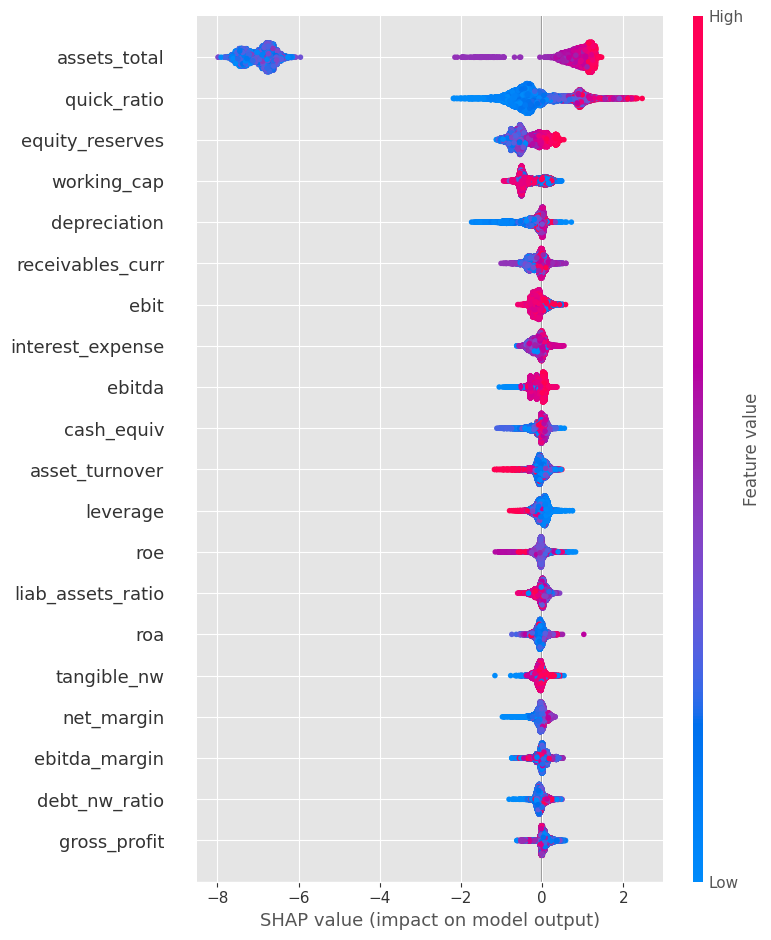

In [28]:
import shap

explainer = shap.Explainer(model_xgb)
shap_values = explainer(X_test_sel)

shap.summary_plot(shap_values, X_test_sel)

assets_total is by far the most influential feature: its SHAP values span from −10 to +2, meaning firm size has an enormous and asymmetric effect on predicted default probability. 

quick_ratio is the second most influential, reaching up to +3. 

The remaining features each contribute a moderate spread of roughly −2 to +2, meaning they all play a meaningful supporting role rather than being negligible. 

The model is not purely driven by one or two variables — it uses the full feature set, with size and liquidity leading.


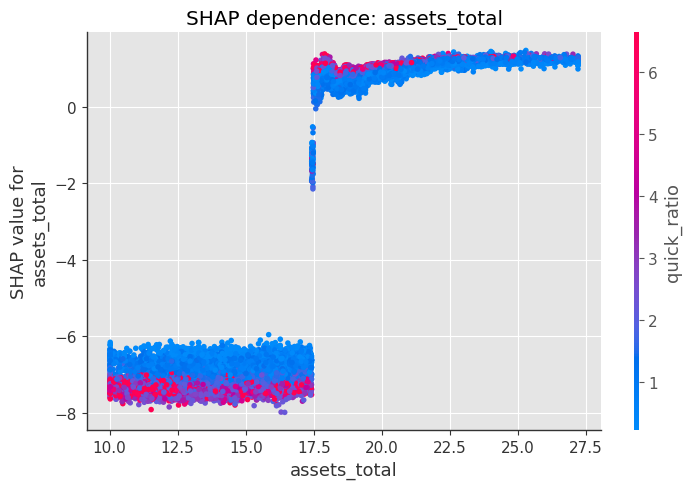

In [29]:
shap.dependence_plot("assets_total", shap_values.values, X_test_sel, show=False)
plt.title("SHAP dependence: assets_total")
plt.tight_layout()
plt.show()


The assets_total dependence plot reveals a sharp structural break at approximately 17.5 on the log scale (corresponding to roughly exp(17.5) − 1 ≈ 40M lions in total assets).

Below this threshold, the model assigns strongly negative SHAP values (−7 to −9), meaning small firms are pushed toward very low predicted PD. 

Above the threshold, SHAP values flip to around 0 to +2, meaning larger firms consistently receive higher predicted default probability.

This is counterintuitive. We would normally expect larger, more established firms to be safer. One explanation is that larger SMEs in this dataset carry disproportionately more debt or operate in more volatile sectors. The color coding (quick_ratio) shows no clear separation between the two clusters, meaning liquidity alone does not explain the split, the break is driven purely by firm size.

This discontinuity suggests that a size-segmented model : separate scorecards for small vs. mid-size SMEs. That could potentially improve performance, which is a common approach in retail credit risk practice.

